# Ensambles, reducción dimensional y Green AI

Compara modelos con una partición estratificada común. Los tiempos y el consumo estimado son indicadores aproximados, dependientes del equipo.

# U01.LAB03 — Ensambles, reducción dimensional y Green AI

## INF-8239 Ciencia de Datos II

### Objetivo

Ampliar el experimento del Ejercicio 01 utilizando el mismo dataset,
target y partición de prueba para comparar modelos de clasificación,
una variante con reducción dimensional y sus costos computacionales.

### Protocolo congelado

- Dataset: Statlog (German Credit Data), UCI
- Observaciones: 1,000
- Variables predictoras: 20
- Target: `class`
- Clases: 1 = Good, 2 = Bad
- División: 80% entrenamiento / 20% prueba
- `random_state`: 42
- División estratificada
- Métrica principal: F1 Macro
- Clase de interés para el análisis: Bad (2)

### Configuraciones

1. Logistic Regression
2. SVM C=1
3. SVM C=10
4. Random Forest 100
5. Random Forest 300
6. HistGradientBoosting
7. SVM + PCA

In [28]:
import sys

PROJECT_ROOT = Path.cwd().parent
SRC_PATH = PROJECT_ROOT / "src"

if str(SRC_PATH) not in sys.path:
    sys.path.insert(0, str(SRC_PATH))

print("Proyecto:", PROJECT_ROOT)
print("SRC:", SRC_PATH)

Proyecto: c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01
SRC: c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\src


In [2]:
from pathlib import Path
from time import perf_counter

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.decomposition import PCA
from sklearn.ensemble import (
    RandomForestClassifier,
    HistGradientBoostingClassifier,
)
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, recall_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.svm import SVC

In [3]:
DATA_PATH = Path("data/raw/dataset.csv")
TARGET = "class"

df = pd.read_csv(DATA_PATH)

X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Dataset:", df.shape)
print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)
print("Clases entrenamiento:")
print(y_train.value_counts().sort_index())
print("Clases prueba:")
print(y_test.value_counts().sort_index())

Dataset: (1000, 21)
Entrenamiento: (800, 20)
Prueba: (200, 20)
Clases entrenamiento:
class
1    560
2    240
Name: count, dtype: int64
Clases prueba:
class
1    140
2     60
Name: count, dtype: int64


In [6]:
numeric_columns = [
    "Attribute2",
    "Attribute5",
    "Attribute8",
    "Attribute11",
    "Attribute13",
    "Attribute16",
    "Attribute18",
]

categorical_columns = [
    "Attribute1",
    "Attribute3",
    "Attribute4",
    "Attribute6",
    "Attribute7",
    "Attribute9",
    "Attribute10",
    "Attribute12",
    "Attribute14",
    "Attribute15",
    "Attribute17",
    "Attribute19",
    "Attribute20",
]

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scale", StandardScaler()),
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, numeric_columns),
    ("cat", categorical_pipeline, categorical_columns),
])

In [7]:
X_train_prepared = preprocess.fit_transform(X_train)

print("Forma original:", X_train.shape)
print("Forma después del preprocesamiento:", X_train_prepared.shape)
print("Tipo de matriz:", type(X_train_prepared))

Forma original: (800, 20)
Forma después del preprocesamiento: (800, 61)
Tipo de matriz: <class 'numpy.ndarray'>


In [8]:
models = {
    "logistic": Pipeline([
        ("prep", preprocess),
        ("model", LogisticRegression(max_iter=2000))
    ]),

    "svm_c1": Pipeline([
        ("prep", preprocess),
        ("model", SVC(
            C=1,
            probability=True,
            random_state=42
        ))
    ]),

    "svm_c10": Pipeline([
        ("prep", preprocess),
        ("model", SVC(
            C=10,
            probability=True,
            random_state=42
        ))
    ]),

    "rf_100": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=100,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "rf_300": Pipeline([
        ("prep", preprocess),
        ("model", RandomForestClassifier(
            n_estimators=300,
            max_depth=8,
            random_state=42,
            n_jobs=-1
        ))
    ]),

    "boost": Pipeline([
        ("prep", preprocess),
        ("model", HistGradientBoostingClassifier(
            max_depth=6,
            random_state=42
        ))
    ]),
}

In [9]:
print(models.keys())

dict_keys(['logistic', 'svm_c1', 'svm_c10', 'rf_100', 'rf_300', 'boost'])


In [12]:
rows = []

for name, model in models.items():
    fit_times = []

    for repetition in range(3):
        start = perf_counter()
        model.fit(X_train, y_train)
        fit_times.append(perf_counter() - start)

    start = perf_counter()
    pred = model.predict(X_test)
    predict_ms = (perf_counter() - start) * 1000

    path = MODELS_DIR / f"{name}.joblib"
    joblib.dump(model, path)

    rows.append({
        "model": name,
        "f1_macro": f1_score(
            y_test,
            pred,
            average="macro"
        ),
        "recall_macro": recall_score(
            y_test,
            pred,
            average="macro"
        ),
        "fit_median_s": np.median(fit_times),
        "predict_ms": predict_ms,
        "size_kb": path.stat().st_size / 1024
    })

results = pd.DataFrame(rows)

results.sort_values(
    "f1_macro",
    ascending=False
)

c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Li

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
0,logistic,0.720954,0.709524,0.088639,25.9600,7.916016
1,svm_c1,0.720000,0.702381,0.404473,73.8966,268.724609
2,svm_c10,0.696120,0.700000,0.792514,64.2953,277.646484
5,boost,0.688150,0.676190,0.705587,38.6624,209.814453
3,rf_100,0.669494,0.653571,0.752279,58.0897,1254.635742
4,rf_300,0.664918,0.650000,0.950452,221.4247,3745.573242


In [13]:
svm_pca = Pipeline([
    ("prep", preprocess),
    ("pca", PCA(
        n_components=0.95,
        random_state=42
    )),
    ("model", SVC(
        C=1,
        probability=True,
        random_state=42
    ))
])

In [15]:
svm_pca.fit(X_train, y_train)

print(
    "Componentes:",
    svm_pca.named_steps["pca"].n_components_
)

c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


Componentes: 32


In [16]:
fit_times = []

for repetition in range(3):
    start = perf_counter()
    svm_pca.fit(X_train, y_train)
    fit_times.append(perf_counter() - start)

start = perf_counter()
pred = svm_pca.predict(X_test)
predict_ms = (perf_counter() - start) * 1000

path = MODELS_DIR / "svm_pca.joblib"
joblib.dump(svm_pca, path)

pca_result = {
    "model": "svm_pca",
    "f1_macro": f1_score(
        y_test,
        pred,
        average="macro"
    ),
    "recall_macro": recall_score(
        y_test,
        pred,
        average="macro"
    ),
    "fit_median_s": np.median(fit_times),
    "predict_ms": predict_ms,
    "size_kb": path.stat().st_size / 1024
}

print(pca_result)

c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(
c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\.venv\Lib\site-packages\sklearn\svm\_base.py:236: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


{'model': 'svm_pca', 'f1_macro': 0.6881496881496881, 'recall_macro': 0.6761904761904762, 'fit_median_s': np.float64(0.3344970000325702), 'predict_ms': 40.37969995988533, 'size_kb': 170.693359375}


In [17]:
results = pd.concat(
    [
        results,
        pd.DataFrame([pca_result])
    ],
    ignore_index=True
)

results = results.sort_values(
    "f1_macro",
    ascending=False
).reset_index(drop=True)

results

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb
0,logistic,0.720954,0.709524,0.088639,25.9600,7.916016
1,svm_c1,0.720000,0.702381,0.404473,73.8966,268.724609
2,svm_c10,0.696120,0.700000,0.792514,64.2953,277.646484
3,svm_pca,0.688150,0.676190,0.334497,40.3797,170.693359
4,boost,0.688150,0.676190,0.705587,38.6624,209.814453
5,rf_100,0.669494,0.653571,0.752279,58.0897,1254.635742
6,rf_300,0.664918,0.650000,0.950452,221.4247,3745.573242


In [18]:
X_num = X.select_dtypes(include="number").copy()

X_num = X_num.fillna(
    X_num.median()
)

sample = X_num.sample(
    min(1000, len(X_num)),
    random_state=42
)

y_sample = y.loc[sample.index]

scaled = StandardScaler().fit_transform(sample)

print("Observaciones:", scaled.shape[0])
print("Variables numéricas:", scaled.shape[1])

Observaciones: 1000
Variables numéricas: 7


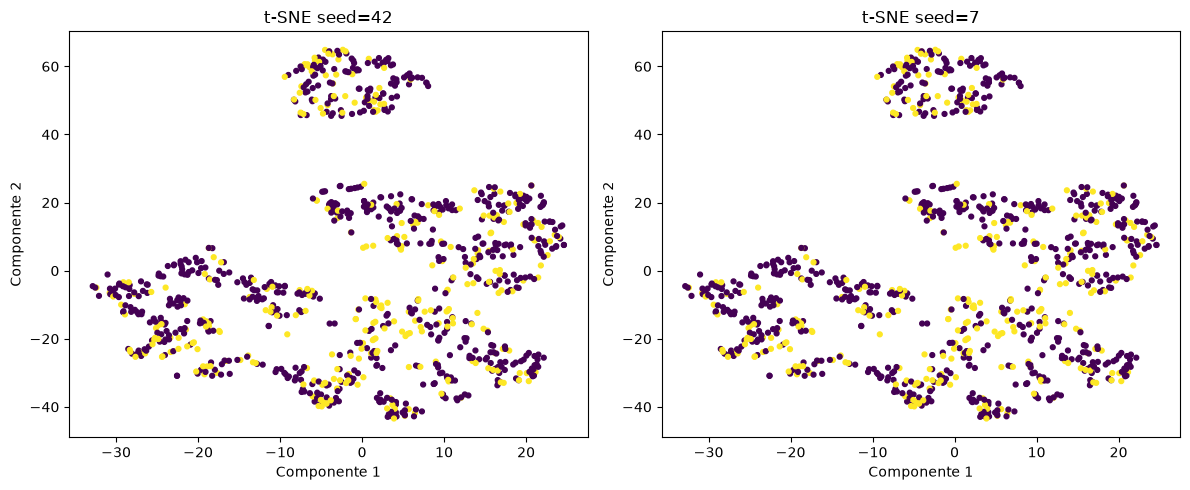

In [19]:
from sklearn.manifold import TSNE

fig, axes = plt.subplots(
    1,
    2,
    figsize=(12, 5)
)

for ax, seed in zip(axes, [42, 7]):
    emb = TSNE(
        n_components=2,
        perplexity=30,
        random_state=seed,
        init="pca",
        learning_rate="auto"
    ).fit_transform(scaled)

    ax.scatter(
        emb[:, 0],
        emb[:, 1],
        c=pd.Categorical(y_sample).codes,
        s=12,
        cmap="viridis"
    )

    ax.set_title(f"t-SNE seed={seed}")
    ax.set_xlabel("Componente 1")
    ax.set_ylabel("Componente 2")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "reports" / "tsne_two_seeds.png",
    dpi=160
)

plt.show()

In [29]:
from inf8239_u01.green import pareto_flags

results["is_pareto"] = pareto_flags(results)

results

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
0,logistic,0.720954,0.709524,0.088639,25.9600,7.916016,True
1,svm_c1,0.720000,0.702381,0.404473,73.8966,268.724609,False
2,svm_c10,0.696120,0.700000,0.792514,64.2953,277.646484,False
3,svm_pca,0.688150,0.676190,0.334497,40.3797,170.693359,False
4,boost,0.688150,0.676190,0.705587,38.6624,209.814453,False
5,rf_100,0.669494,0.653571,0.752279,58.0897,1254.635742,False
6,rf_300,0.664918,0.650000,0.950452,221.4247,3745.573242,False


In [30]:
results["is_pareto"] = pareto_flags(results)

results

,model,f1_macro,recall_macro,fit_median_s,predict_ms,size_kb,is_pareto
0,logistic,0.720954,0.709524,0.088639,25.9600,7.916016,True
1,svm_c1,0.720000,0.702381,0.404473,73.8966,268.724609,False
2,svm_c10,0.696120,0.700000,0.792514,64.2953,277.646484,False
3,svm_pca,0.688150,0.676190,0.334497,40.3797,170.693359,False
4,boost,0.688150,0.676190,0.705587,38.6624,209.814453,False
5,rf_100,0.669494,0.653571,0.752279,58.0897,1254.635742,False
6,rf_300,0.664918,0.650000,0.950452,221.4247,3745.573242,False


In [31]:
results.to_csv(
    PROJECT_ROOT / "reports" / "green_ai_results.csv",
    index=False
)

print("Archivo guardado:")
print(PROJECT_ROOT / "reports" / "green_ai_results.csv")

Archivo guardado:
c:\Users\raine\Desktop\Ciencias de Datos II\INF8239_U01\reports\green_ai_results.csv


In [23]:
print(
    (PROJECT_ROOT / "reports" / "green_ai_results.csv").exists()
)

True


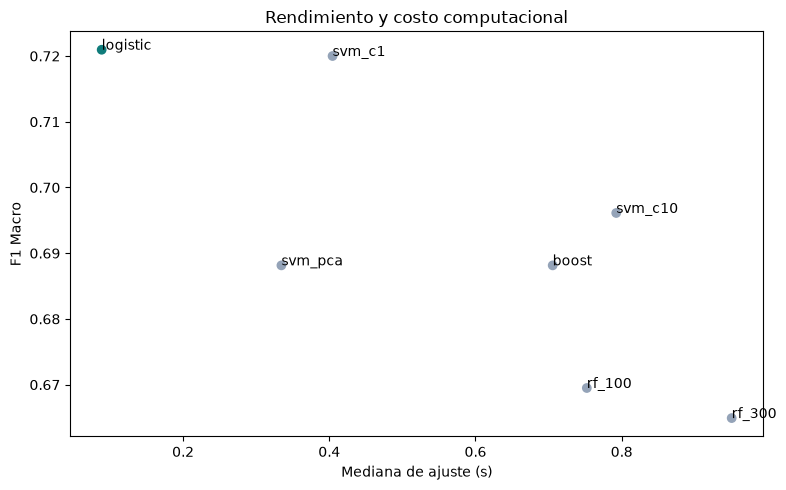

In [24]:
fig, ax = plt.subplots(figsize=(8, 5))

ax.scatter(
    results["fit_median_s"],
    results["f1_macro"],
    c=results["is_pareto"].map({
        True: "#0f7c7b",
        False: "#94a3b8"
    })
)

for _, r in results.iterrows():
    ax.annotate(
        r["model"],
        (
            r["fit_median_s"],
            r["f1_macro"]
        )
    )

ax.set_xlabel("Mediana de ajuste (s)")
ax.set_ylabel("F1 Macro")
ax.set_title("Rendimiento y costo computacional")

plt.tight_layout()

plt.savefig(
    PROJECT_ROOT / "reports" / "pareto.png",
    dpi=160
)

plt.show()

In [25]:
logistic = results[results["model"] == "logistic"].iloc[0]
svm_c1 = results[results["model"] == "svm_c1"].iloc[0]

f1_difference = logistic["f1_macro"] - svm_c1["f1_macro"]

time_saving_pct = (
    (svm_c1["fit_median_s"] - logistic["fit_median_s"])
    / svm_c1["fit_median_s"]
) * 100

size_reduction_pct = (
    (svm_c1["size_kb"] - logistic["size_kb"])
    / svm_c1["size_kb"]
) * 100

predict_reduction_pct = (
    (svm_c1["predict_ms"] - logistic["predict_ms"])
    / svm_c1["predict_ms"]
) * 100

print(f"F1 Macro Logistic: {logistic['f1_macro']:.6f}")
print(f"F1 Macro SVM C=1: {svm_c1['f1_macro']:.6f}")
print(f"Diferencia absoluta de F1: {f1_difference:.6f}")
print(f"Ahorro de tiempo de ajuste: {time_saving_pct:.2f}%")
print(f"Reducción del tamaño del modelo: {size_reduction_pct:.2f}%")
print(f"Reducción del tiempo de inferencia: {predict_reduction_pct:.2f}%")

F1 Macro Logistic: 0.720954
F1 Macro SVM C=1: 0.720000
Diferencia absoluta de F1: 0.000954
Ahorro de tiempo de ajuste: 78.09%
Reducción del tamaño del modelo: 97.05%
Reducción del tiempo de inferencia: 64.87%


In [32]:
csv_path = PROJECT_ROOT / "reports" / "green_ai_results.csv"

print("Existe:", csv_path.exists())
print("Tamaño:", csv_path.stat().st_size, "bytes")

Existe: True
Tamaño: 768 bytes
